# 🤖 AI Research Paper Intelligence System

## Final Demonstration

This notebook demonstrates the complete workflow:

- PDF Extraction
- Text Preprocessing
- Automatic Summarization
- Keyword Extraction
- Analytics
- Semantic Search
- Citation Generation

In [1]:
import os
import sys
import importlib

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.pdf_utils import extract_text_from_pdf
from utils.preprocessing import preprocess
from utils.summarizer import PaperSummarizer
from utils.analytics import PaperAnalytics
from utils.semantic_search import SemanticSearch
from utils.citation import CitationGenerator

import pandas as pd

print("✅ All modules imported successfully!")

✅ All modules imported successfully!


In [2]:
pdf_path = "../uploads/attention_is_all_you_need.pdf"

paper_text = extract_text_from_pdf(pdf_path)

print("Characters:", len(paper_text))

Characters: 39498


In [3]:
tokens = preprocess(paper_text)

print("First 50 Tokens:\n")

print(tokens[:50])


First 50 Tokens:

['provided', 'proper', 'attribution', 'provided', 'google', 'hereby', 'grant', 'permission', 'reproduce', 'table', 'figure', 'paper', 'solely', 'use', 'journalistic', 'scholarly', 'work', 'attention', 'need', 'ashish', 'vaswani', 'google', 'brain', 'avaswani', 'google', 'com', 'noam', 'shazeer', 'google', 'brain', 'noam', 'google', 'com', 'niki', 'parmar', 'google', 'research', 'nikip', 'google', 'com', 'jakob', 'uszkoreit', 'google', 'research', 'usz', 'google', 'com', 'llion', 'jones', 'google']


In [4]:
summarizer = PaperSummarizer()

summary = summarizer.summarize(
    paper_text,
    sentences=8
)

print("===== SUMMARY =====\n")

for sentence in summary:
    print(sentence)
    print()

===== SUMMARY =====

We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely.

Self-attention has been used successfully in a variety of tasks including reading comprehension, abstractive summarization, textual entailment and learning task-independent sentence representations [4, 27, 28, 22].

We also experimented with using learned positional embeddings [9] instead, and found that the two versions produced nearly identical results (see Table 3 row (E)).

A single convolutional layer with kernel width k < n does not connect all pairs of input and output positions.

5.1 Training Data and Batching We trained on the standard WMT 2014 English-German dataset consisting of about 4.5 million sentence pairs.

We also trained it in a semi-supervised setting, using the larger high-confidence and BerkleyParser corpora from with approximately 17M sentences [37].

During inference, we 9 Table 4: The Tr

In [5]:
keywords = summarizer.keywords(
    paper_text,
    top_n=15
)

print("===== KEYWORDS =====\n")

for keyword, score in keywords:
    print(keyword)

===== KEYWORDS =====

Attention
arXiv preprint arXiv
model
models
Transformer
Neural machine translation
scaled dot-product attention
sequence
layer
arXiv
arXiv preprint
preprint arXiv
Neural Information Processing
output
neural


In [6]:
analytics = PaperAnalytics(paper_text)

analytics.statistics()

{'Characters': 39498,
 'Words': 4584,
 'Unique Words': 1328,
 'Estimated Reading Time (minutes)': 22.92}

In [7]:
analytics.frequent_words()

,Word,Frequency
0,the,338
1,and,177
2,attention,93
3,for,51
4,model,45
5,this,42
6,sequence,40
7,with,39
8,models,37
9,layer,36


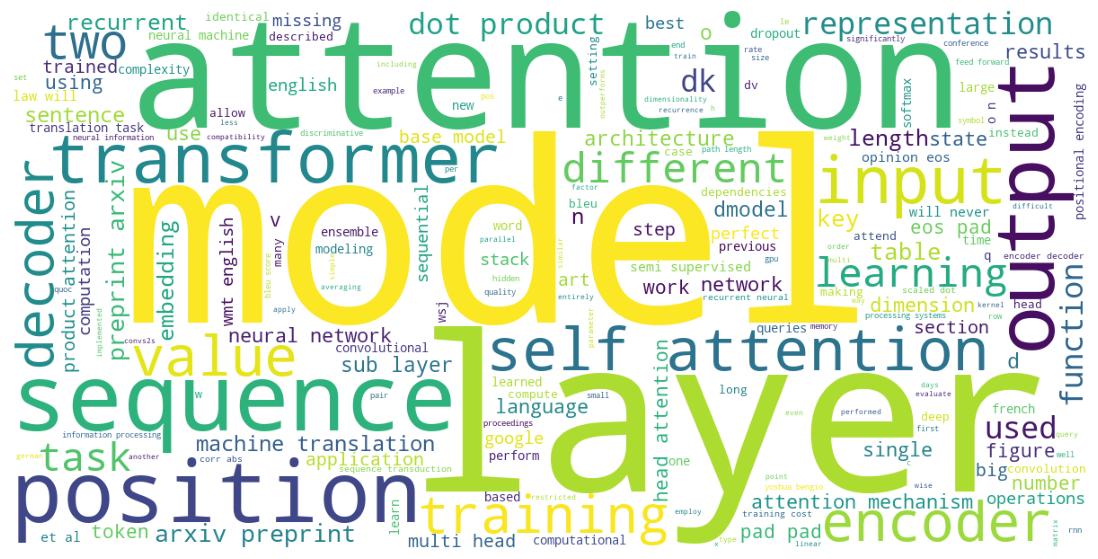

In [8]:
analytics.word_cloud()

In [9]:
papers = pd.read_csv("../data/cleaned_papers.csv")

papers = papers[["title","abstract"]]

papers = papers.sample(
    5000,
    random_state=42
).reset_index(drop=True)

engine = SemanticSearch()

embeddings = engine.create_embeddings(
    papers
)

engine.build_index(embeddings)

results = engine.search(
    "Transformer models for NLP"
)

results

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

✅ Indexed 5000 papers.


,title,abstract
2364,WaLDORf: Wasteless Language-model Distillation...,Transformer based Very Large Language Models...
4089,Conditioned Natural Language Generation using ...,Transformer-based language models have shown...
4436,Learning to Merge Tokens in Vision Transformers,Transformers are widely applied to solve nat...
3211,DeFINE: DEep Factorized INput Token Embeddings...,"For sequence models with large vocabularies,..."
4405,Transformer Acceleration with Dynamic Sparse A...,Transformers are the mainstream of NLP appli...


In [10]:
citation = CitationGenerator(
    title="Attention Is All You Need",
    authors="Ashish Vaswani et al.",
    year="2017"
)

print("APA\n")
print(citation.apa())

print("\nIEEE\n")
print(citation.ieee())

print("\nMLA\n")
print(citation.mla())

APA

Ashish Vaswani et al. (2017). Attention Is All You Need.

IEEE

Ashish Vaswani et al., "Attention Is All You Need," 2017.

MLA

Ashish Vaswani et al.. "Attention Is All You Need." 2017.


In [11]:
print("""
===========================================

AI Research Paper Intelligence System

Modules Completed

✔ PDF Extraction

✔ Text Cleaning

✔ Semantic Search

✔ Automatic Summarization

✔ Keyword Extraction

✔ Analytics

✔ Citation Generator

===========================================

Project Successfully Completed!

===========================================
""")



AI Research Paper Intelligence System

Modules Completed

✔ PDF Extraction

✔ Text Cleaning

✔ Semantic Search

✔ Automatic Summarization

✔ Keyword Extraction

✔ Analytics

✔ Citation Generator


Project Successfully Completed!


